# Action Signal Analysis

This notebook analyzes the frequency content of executed robot actions to:
1. Characterize servo jitter (frequency, amplitude, bandwidth)
2. Determine optimal low-pass filter parameters
3. Recommend deadband and alpha values for the adaptive filter

## Data Collection

First, run the robot client with experiment metrics enabled:

```python
client_cfg = RobotClientImprovedConfig(
    # ... your config ...
    experiment_metrics_path="results/jitter_analysis.csv",
    action_lowpass_enabled=False,  # Disable filter to capture raw jitter
)
```

Let the robot sit at rest for ~30 seconds, then stop. This produces:
- `results/jitter_analysis.csv` - per-tick metrics
- `results/jitter_analysis.trajectory.json` - executed actions with timestamps

In [6]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Configure matplotlib for better plots
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

## 1. Load Data

In [7]:
# Path to your trajectory JSON file
TRAJECTORY_PATH = Path("../../results/jitter_analysis.trajectory.json")

# Load trajectory data
with open(TRAJECTORY_PATH) as f:
    data = json.load(f)

executed = data["executed"]
print(f"Loaded {len(executed)} executed actions")

# Extract arrays
timestamps = np.array([e["t"] for e in executed])
steps = np.array([e["step"] for e in executed])
actions = np.array([e["action"] for e in executed])  # Shape: (N, num_joints)

num_samples, num_joints = actions.shape
print(f"Shape: {actions.shape} ({num_samples} samples, {num_joints} joints)")

# Compute sample rate from timestamps
dt = np.diff(timestamps)
sample_rate = 1.0 / np.median(dt)
duration = timestamps[-1] - timestamps[0]
print(f"Duration: {duration:.1f}s, Sample rate: {sample_rate:.1f} Hz")

Loaded 1532 executed actions
Shape: (1532, 6) (1532 samples, 6 joints)
Duration: 25.7s, Sample rate: 60.0 Hz


## 2. Time Domain Analysis

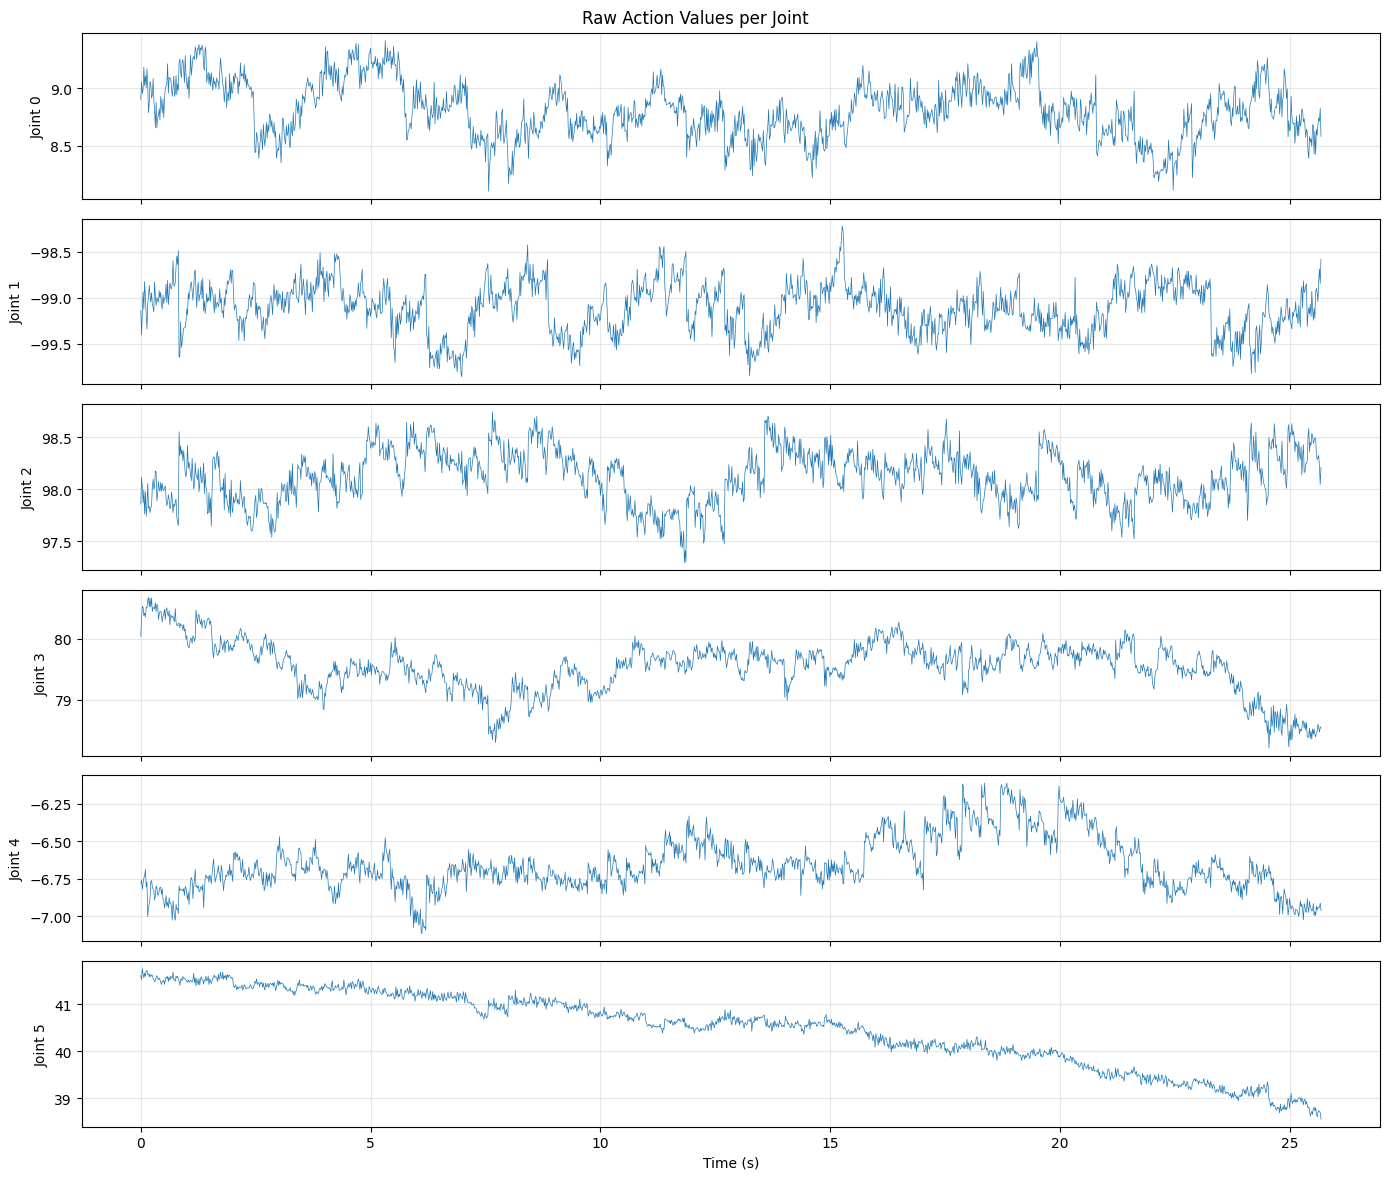

In [8]:
# Plot raw action values per joint
t_relative = timestamps - timestamps[0]  # Time from start

fig, axes = plt.subplots(num_joints, 1, figsize=(14, 2 * num_joints), sharex=True)
if num_joints == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(t_relative, actions[:, i], linewidth=0.5)
    ax.set_ylabel(f"Joint {i}")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw Action Values per Joint", fontsize=12)
plt.tight_layout()
plt.show()

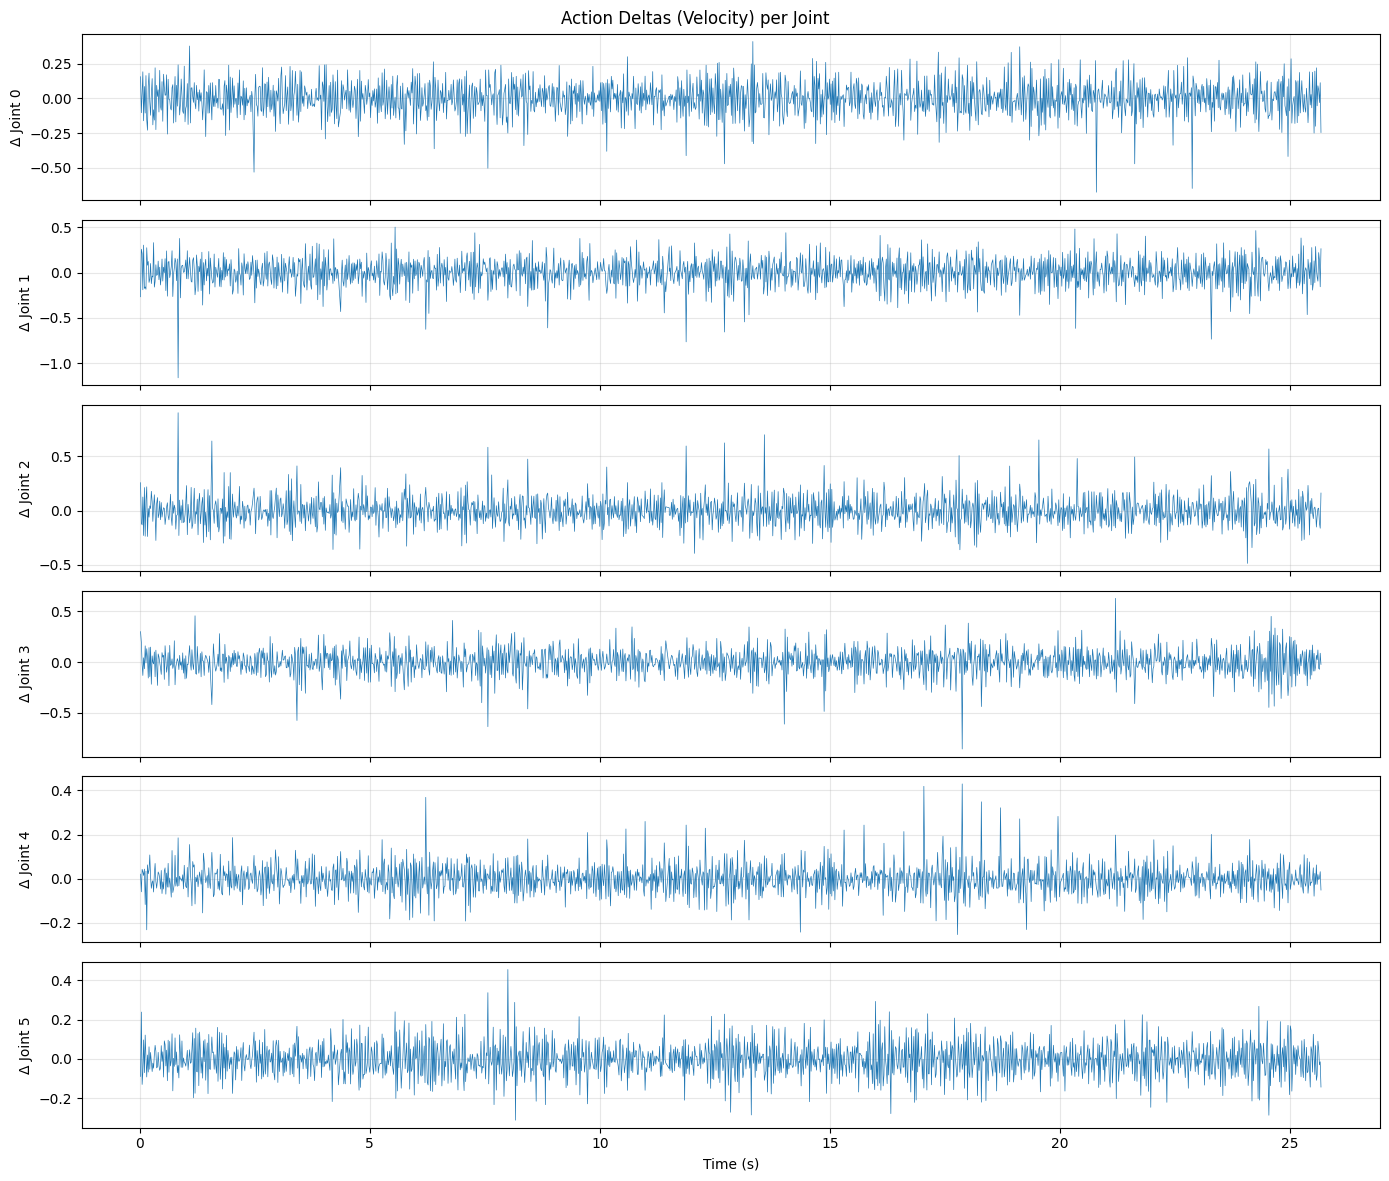

Delta Statistics (radians):
  Joint 0: mean=-0.000210, std=0.124088, max=0.674902
  Joint 1: mean=0.000364, std=0.159095, max=1.161652
  Joint 2: mean=0.000230, std=0.135933, max=0.900810
  Joint 3: mean=-0.000982, std=0.130342, max=0.858429
  Joint 4: mean=-0.000119, std=0.068548, max=0.429109
  Joint 5: mean=-0.001994, std=0.086998, max=0.453636


In [9]:
# Compute action deltas (discrete velocity)
deltas = np.diff(actions, axis=0)

# Plot deltas
fig, axes = plt.subplots(num_joints, 1, figsize=(14, 2 * num_joints), sharex=True)
if num_joints == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(t_relative[1:], deltas[:, i], linewidth=0.5)
    ax.set_ylabel(f"Δ Joint {i}")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Action Deltas (Velocity) per Joint", fontsize=12)
plt.tight_layout()
plt.show()

# Summary statistics
print("Delta Statistics (radians):")
for i in range(num_joints):
    d = deltas[:, i]
    print(f"  Joint {i}: mean={np.mean(d):.6f}, std={np.std(d):.6f}, "
          f"max={np.max(np.abs(d)):.6f}")

## 3. Frequency Domain Analysis (FFT)

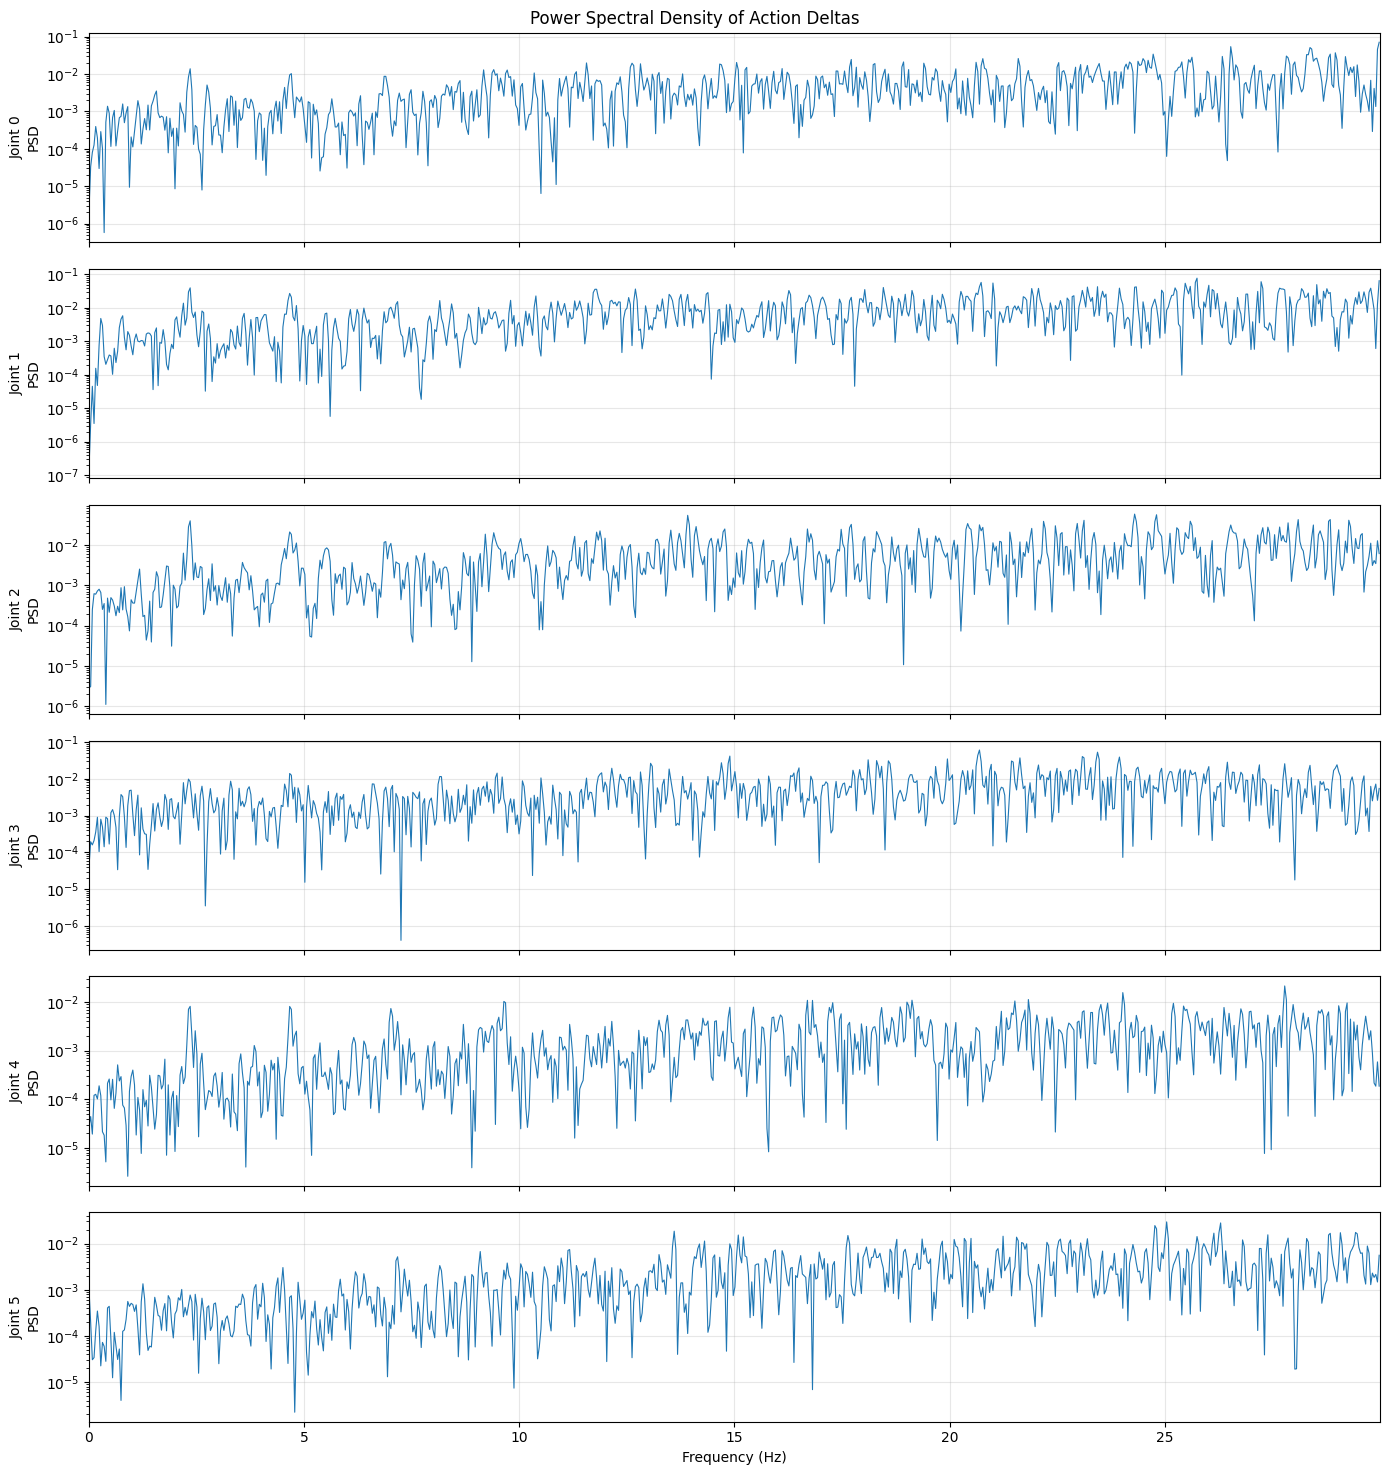

In [10]:
def compute_psd(signal, sample_rate):
    """Compute power spectral density using FFT."""
    n = len(signal)
    # Apply Hanning window to reduce spectral leakage
    window = np.hanning(n)
    windowed = signal * window
    
    # Compute FFT
    fft_result = np.fft.rfft(windowed)
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)
    
    # Power spectral density (normalized)
    psd = np.abs(fft_result) ** 2 / n
    
    return freqs, psd


# Compute PSD for each joint's delta signal
fig, axes = plt.subplots(num_joints, 1, figsize=(14, 2.5 * num_joints), sharex=True)
if num_joints == 1:
    axes = [axes]

joint_psds = []
for i, ax in enumerate(axes):
    freqs, psd = compute_psd(deltas[:, i], sample_rate)
    joint_psds.append((freqs, psd))
    
    ax.semilogy(freqs, psd, linewidth=0.8)
    ax.set_ylabel(f"Joint {i}\nPSD")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, sample_rate / 2)

axes[-1].set_xlabel("Frequency (Hz)")
fig.suptitle("Power Spectral Density of Action Deltas", fontsize=12)
plt.tight_layout()
plt.show()

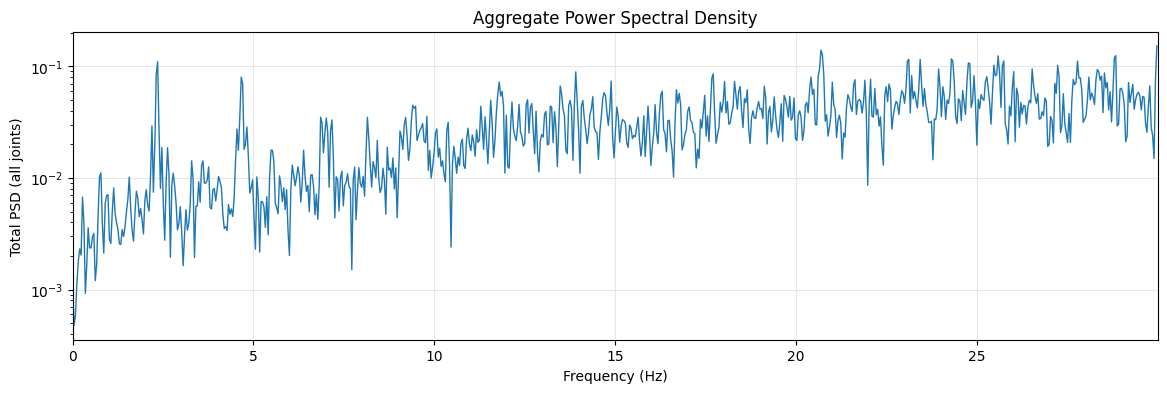

Dominant frequencies:
  29.98 Hz (power: 1.53e-01)
  20.69 Hz (power: 1.40e-01)
  20.73 Hz (power: 1.28e-01)
  28.84 Hz (power: 1.25e-01)
  25.59 Hz (power: 1.24e-01)


In [11]:
# Aggregate PSD across all joints
freqs = joint_psds[0][0]
total_psd = sum(psd for _, psd in joint_psds)

plt.figure(figsize=(14, 4))
plt.semilogy(freqs, total_psd, linewidth=1)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Total PSD (all joints)")
plt.title("Aggregate Power Spectral Density")
plt.grid(True, alpha=0.3)
plt.xlim(0, sample_rate / 2)
plt.show()

# Find dominant frequencies
peak_idx = np.argsort(total_psd)[-5:][::-1]  # Top 5 peaks
print("Dominant frequencies:")
for idx in peak_idx:
    if freqs[idx] > 0:  # Skip DC
        print(f"  {freqs[idx]:.2f} Hz (power: {total_psd[idx]:.2e})")

## 4. Jitter Characterization

In [12]:
# Analyze power distribution across frequency bands
def analyze_frequency_bands(freqs, psd, sample_rate):
    """Compute power in different frequency bands."""
    nyquist = sample_rate / 2
    
    # Define bands (Hz)
    bands = [
        ("DC/very low", 0, 0.5),
        ("Low (intentional motion)", 0.5, 5),
        ("Medium", 5, 15),
        ("High (jitter)", 15, nyquist),
    ]
    
    total_power = np.sum(psd)
    results = []
    
    for name, low, high in bands:
        mask = (freqs >= low) & (freqs < high)
        band_power = np.sum(psd[mask])
        fraction = band_power / total_power if total_power > 0 else 0
        results.append((name, low, high, band_power, fraction))
    
    return results


print("Power Distribution by Frequency Band:")
print("=" * 60)
band_results = analyze_frequency_bands(freqs, total_psd, sample_rate)
for name, low, high, power, fraction in band_results:
    bar = "█" * int(fraction * 40)
    print(f"{name:25s} [{low:5.1f}-{high:5.1f} Hz]: {fraction*100:5.1f}% {bar}")

Power Distribution by Frequency Band:
DC/very low               [  0.0-  0.5 Hz]:   0.1% 
Low (intentional motion)  [  0.5-  5.0 Hz]:   4.9% █
Medium                    [  5.0- 15.0 Hz]:  22.3% ████████
High (jitter)             [ 15.0- 30.0 Hz]:  72.7% █████████████████████████████


In [13]:
# Compute optimal cutoff frequency for low-pass filter
# Find frequency where cumulative power reaches 90%, 95%, 99%

cumsum = np.cumsum(total_psd)
total = cumsum[-1]

thresholds = [0.90, 0.95, 0.99]
print("Cumulative Power Analysis:")
for thresh in thresholds:
    idx = np.searchsorted(cumsum, thresh * total)
    cutoff_freq = freqs[min(idx, len(freqs)-1)]
    print(f"  {thresh*100:.0f}% of power below {cutoff_freq:.2f} Hz")

# Suggested cutoff: where 95% of power is captured
idx_95 = np.searchsorted(cumsum, 0.95 * total)
suggested_cutoff = freqs[min(idx_95, len(freqs)-1)]
print(f"\nSuggested low-pass cutoff: {suggested_cutoff:.1f} Hz")

Cumulative Power Analysis:
  90% of power below 28.29 Hz
  95% of power below 29.04 Hz
  99% of power below 29.86 Hz

Suggested low-pass cutoff: 29.0 Hz


## 5. Filter Parameter Recommendations

In [14]:
# Compute recommended parameters based on analysis

# Deadband: based on jitter amplitude (std of deltas)
# Use 2-3x the standard deviation of deltas as deadband
delta_stds = np.std(deltas, axis=0)
mean_delta_std = np.mean(delta_stds)
recommended_deadband = 2.5 * mean_delta_std

# Alpha values for IIR filter
# alpha relates to cutoff: alpha ≈ 2π * fc * dt / (2π * fc * dt + 1)
# For heavy smoothing (jitter), use low alpha
# For fast response (motion), use high alpha
dt_median = 1.0 / sample_rate

# alpha_min: for jitter suppression (low cutoff, e.g., 5 Hz)
fc_low = 5.0  # Hz
alpha_min = (2 * np.pi * fc_low * dt_median) / (2 * np.pi * fc_low * dt_median + 1)

# alpha_max: for fast response (high cutoff, e.g., 20 Hz)
fc_high = 20.0  # Hz
alpha_max = (2 * np.pi * fc_high * dt_median) / (2 * np.pi * fc_high * dt_median + 1)

print("="*60)
print("RECOMMENDED FILTER PARAMETERS")
print("="*60)
print(f"\nBased on sample rate: {sample_rate:.1f} Hz")
print(f"Mean delta std: {mean_delta_std:.6f} rad ({np.degrees(mean_delta_std):.4f}°)")
print()
print("Adaptive Low-Pass Filter Config:")
print(f"  action_lowpass_enabled = True")
print(f"  action_lowpass_alpha_min = {alpha_min:.3f}  # ~{fc_low:.0f} Hz cutoff")
print(f"  action_lowpass_alpha_max = {alpha_max:.3f}  # ~{fc_high:.0f} Hz cutoff")
print(f"  action_lowpass_deadband = {recommended_deadband:.4f}  # {np.degrees(recommended_deadband):.2f}°")
print()

RECOMMENDED FILTER PARAMETERS

Based on sample rate: 60.0 Hz
Mean delta std: 0.117501 rad (6.7323°)

Adaptive Low-Pass Filter Config:
  action_lowpass_enabled = True
  action_lowpass_alpha_min = 0.344  # ~5 Hz cutoff
  action_lowpass_alpha_max = 0.677  # ~20 Hz cutoff
  action_lowpass_deadband = 0.2938  # 16.83°



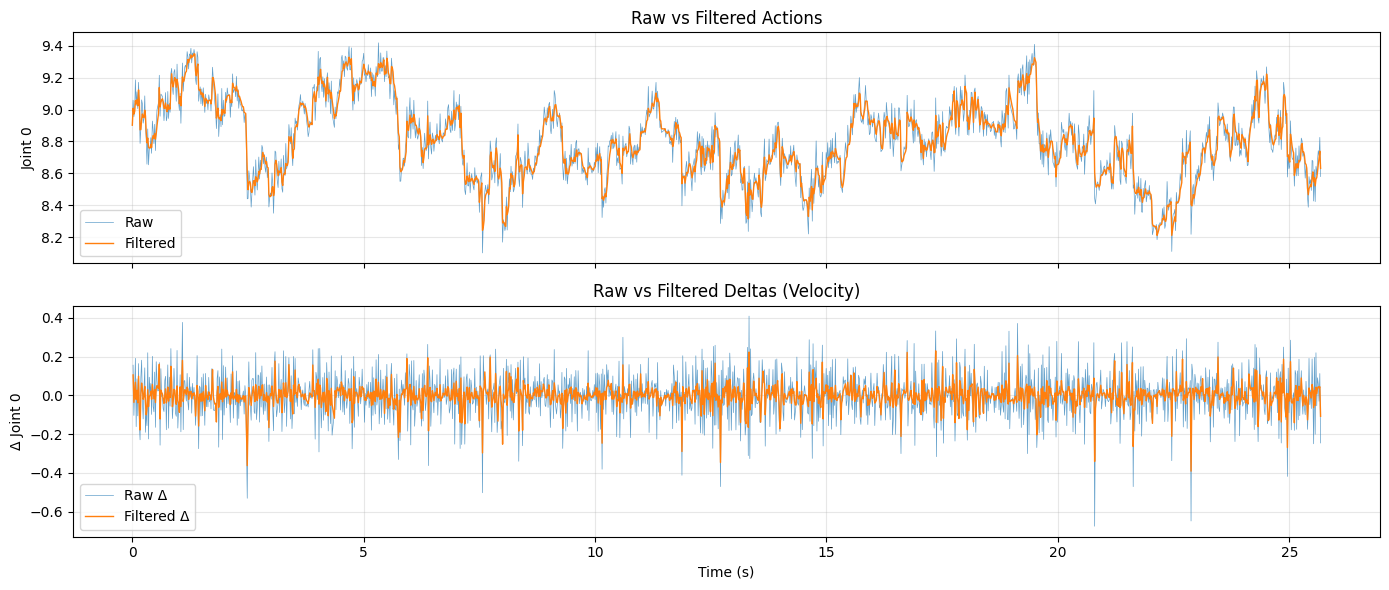

Jitter reduction for joint 0:
  Raw delta std: 0.124088 rad
  Filtered delta std: 0.059203 rad
  Reduction: 52.3%


In [15]:
# Visualize what the filter would do
def simulate_adaptive_filter(actions, alpha_min, alpha_max, deadband):
    """Simulate the adaptive low-pass filter on action data."""
    filtered = np.zeros_like(actions)
    filtered[0] = actions[0]
    
    for i in range(1, len(actions)):
        delta = np.linalg.norm(actions[i] - filtered[i-1])
        if delta > deadband:
            alpha = alpha_max
        else:
            alpha = alpha_min
        filtered[i] = alpha * actions[i] + (1 - alpha) * filtered[i-1]
    
    return filtered


# Apply filter with recommended parameters
filtered = simulate_adaptive_filter(actions, alpha_min, alpha_max, recommended_deadband)

# Plot comparison for first joint
joint_idx = 0
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t_relative, actions[:, joint_idx], linewidth=0.5, label="Raw", alpha=0.7)
axes[0].plot(t_relative, filtered[:, joint_idx], linewidth=1, label="Filtered")
axes[0].set_ylabel(f"Joint {joint_idx}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Raw vs Filtered Actions")

# Deltas comparison
raw_deltas = np.diff(actions[:, joint_idx])
filtered_deltas = np.diff(filtered[:, joint_idx])

axes[1].plot(t_relative[1:], raw_deltas, linewidth=0.5, label="Raw Δ", alpha=0.7)
axes[1].plot(t_relative[1:], filtered_deltas, linewidth=1, label="Filtered Δ")
axes[1].set_ylabel(f"Δ Joint {joint_idx}")
axes[1].set_xlabel("Time (s)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_title("Raw vs Filtered Deltas (Velocity)")

plt.tight_layout()
plt.show()

# Quantify improvement
raw_delta_std = np.std(raw_deltas)
filtered_delta_std = np.std(filtered_deltas)
reduction = (1 - filtered_delta_std / raw_delta_std) * 100

print(f"Jitter reduction for joint {joint_idx}:")
print(f"  Raw delta std: {raw_delta_std:.6f} rad")
print(f"  Filtered delta std: {filtered_delta_std:.6f} rad")
print(f"  Reduction: {reduction:.1f}%")

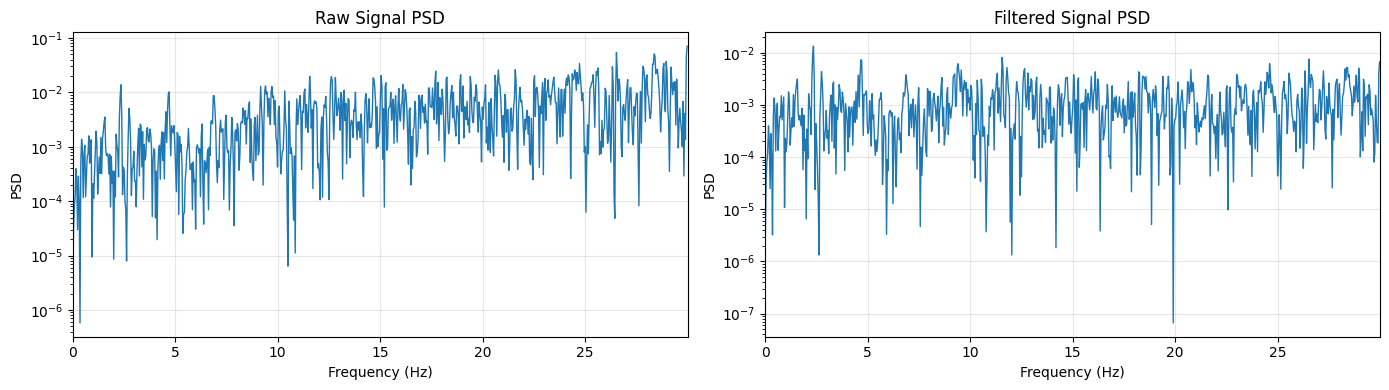

High-frequency (>15 Hz) power reduction: 84.2%


In [16]:
# Compare PSD before and after filtering
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw PSD
freqs_raw, psd_raw = compute_psd(np.diff(actions[:, joint_idx]), sample_rate)
axes[0].semilogy(freqs_raw, psd_raw, linewidth=1)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("PSD")
axes[0].set_title("Raw Signal PSD")
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, sample_rate / 2)

# Filtered PSD
freqs_filt, psd_filt = compute_psd(np.diff(filtered[:, joint_idx]), sample_rate)
axes[1].semilogy(freqs_filt, psd_filt, linewidth=1)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD")
axes[1].set_title("Filtered Signal PSD")
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, sample_rate / 2)

plt.tight_layout()
plt.show()

# High-frequency power reduction
hf_mask = freqs_raw > 15  # Hz
hf_power_raw = np.sum(psd_raw[hf_mask])
hf_power_filt = np.sum(psd_filt[hf_mask])
hf_reduction = (1 - hf_power_filt / hf_power_raw) * 100 if hf_power_raw > 0 else 0

print(f"High-frequency (>15 Hz) power reduction: {hf_reduction:.1f}%")

## 6. Copy-Paste Config

Copy the recommended values into your `RobotClientImprovedConfig`:

In [17]:
# Final recommendations with code snippet
print("# Add to your RobotClientImprovedConfig:")
print(f"action_lowpass_enabled=True,")
print(f"action_lowpass_alpha_min={alpha_min:.3f},")
print(f"action_lowpass_alpha_max={alpha_max:.3f},")
print(f"action_lowpass_deadband={recommended_deadband:.4f},")

# Add to your RobotClientImprovedConfig:
action_lowpass_enabled=True,
action_lowpass_alpha_min=0.344,
action_lowpass_alpha_max=0.677,
action_lowpass_deadband=0.2938,
